# Speech Emotion Detection from Audio
**Hexovate Solutions - AI/ML Internship Assessment (Task 3 of 3)**

**Goal:** predict the emotion (`angry`, `happy`, `sad`, `neutral`) of a short speech clip using the RAVDESS dataset.

**Main model:** SVM / Random Forest (scikit-learn) on audio features - `class_weight="balanced"`, tested on **unseen actors**.
**Optional:** small CNN on mel spectrograms (Section 10).

| # | Section |
|---|---|
| 1 | Setup |
| 2 | Load data |
| 3 | Exploration |
| 4 | Feature extraction |
| 5 | Actor-based split |
| 6 | Training and tuning |
| 7 | Evaluation |
| 8 | Save model + metrics |
| 9 | Error analysis |
| 10 | Optional CNN |

## 1. Setup

In [23]:
import os, glob, json, zlib, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import librosa, librosa.display
import joblib
from joblib import Parallel, delayed

from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GroupKFold, GridSearchCV
from sklearn.metrics import (accuracy_score, f1_score, classification_report,
                             confusion_matrix, ConfusionMatrixDisplay)

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")

SEED         = 42
SR           = 22050
N_MFCC       = 40
TRAIN_ACTORS = list(range(1, 19))
TEST_ACTORS  = list(range(19, 25))
EMOTION_MAP  = {"01": "neutral", "03": "happy", "04": "sad", "05": "angry"}
CLASSES      = ["angry", "happy", "neutral", "sad"]
AUG_KINDS    = ["noise", "stretch", "pitch"]
RUN_CNN      = False
OUT_DIR      = "."

np.random.seed(SEED)

## 2. Load the data

RAVDESS file names look like `03-01-05-01-02-01-12.wav`: the **2nd** number is the vocal channel (01 = speech), the **3rd** is the **emotion**, and the **7th** is the **actor ID** (needed for the split). We keep speech only, 4 emotions, and remove duplicate copies of the same file.

In [24]:
def find_data_dir():
    candidates = ["/kaggle/input", os.environ.get("RAVDESS_DIR"), "ravdess", "data"]
    for c in candidates:
        if c and os.path.isdir(c) and glob.glob(os.path.join(c, "**", "*.wav"), recursive=True):
            return c
    raise FileNotFoundError(
        "No .wav files found. On Kaggle: click 'Add Input' and add the RAVDESS dataset. "
        "Elsewhere: set the RAVDESS_DIR environment variable to the dataset folder.")

DATA_DIR = find_data_dir()
print("Data folder:", DATA_DIR)

Data folder: /kaggle/input


In [25]:
rows = []
all_wavs = glob.glob(os.path.join(DATA_DIR, "**", "*.wav"), recursive=True)
print("Total wav files found:", len(all_wavs))

for path in all_wavs:
    parts = os.path.basename(path)[:-4].split("-")
    if len(parts) != 7:
        continue
    if parts[1] == "01" and parts[2] in EMOTION_MAP:
        rows.append({"path": path, "file": os.path.basename(path),
                     "emotion": EMOTION_MAP[parts[2]], "actor": int(parts[6])})

df = pd.DataFrame(rows)
n_before = len(df)
df = (df.drop_duplicates(subset="file").drop(columns="file")
        .sort_values(["actor", "path"]).reset_index(drop=True))
print(f"Clips before removing duplicates: {n_before} | after: {len(df)}")

counts = df["emotion"].value_counts().reindex(CLASSES)
print(counts)
assert len(df) == 672, "Expected 672 clips - check the dataset folder"
assert counts["neutral"] == 96 and counts[["angry", "happy", "sad"]].eq(192).all()
assert df["actor"].nunique() == 24
print("\nAll checks passed.")

Total wav files found: 2880
Clips before removing duplicates: 1344 | after: 672
emotion
angry      192
happy      192
neutral     96
sad        192
Name: count, dtype: int64

All checks passed.


## 3. Data exploration

### 3.1 Clips per emotion

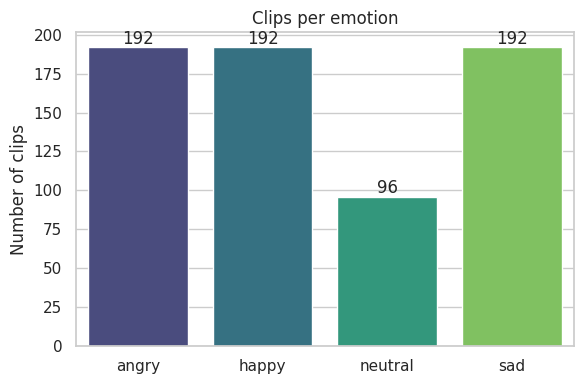

In [26]:
fig, ax = plt.subplots(figsize=(6, 4))
sns.barplot(x=counts.index, y=counts.values, ax=ax, palette="viridis")
for i, v in enumerate(counts.values):
    ax.text(i, v + 2, str(v), ha="center")
ax.set_title("Clips per emotion"); ax.set_ylabel("Number of clips"); ax.set_xlabel("")
plt.tight_layout(); plt.savefig(f"{OUT_DIR}/class_counts.png", dpi=150); plt.show()

**Observation:** `neutral` has only 96 clips, half of the other classes (RAVDESS has no 'strong' neutral). The data is imbalanced, so we use `class_weight='balanced'` and report **macro F1** next to accuracy.

### 3.2 One waveform and one mel spectrogram per emotion

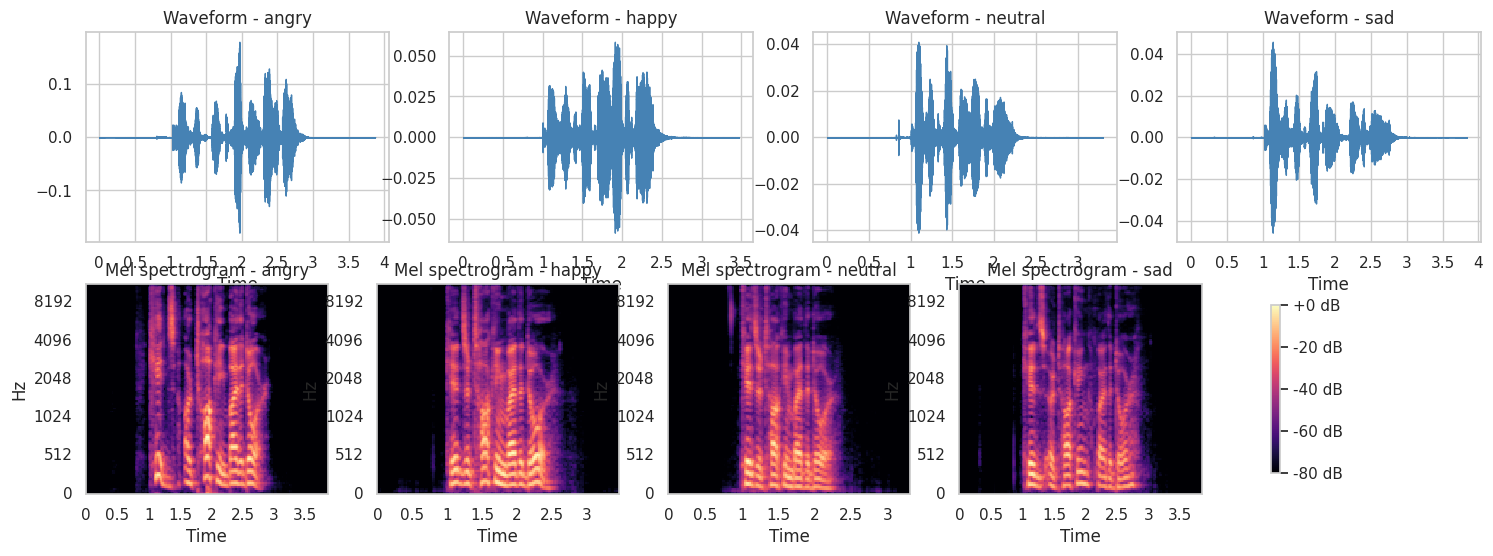

In [27]:
examples = {e: df[(df.emotion == e) & (df.actor == 1)].iloc[0]["path"] for e in CLASSES}

fig, axes = plt.subplots(2, 4, figsize=(18, 6))
for i, (emo, path) in enumerate(examples.items()):
    y, sr = librosa.load(path, sr=SR)
    librosa.display.waveshow(y, sr=sr, ax=axes[0, i], color="steelblue")
    axes[0, i].set_title(f"Waveform - {emo}")
    mel = librosa.power_to_db(librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128), ref=np.max)
    img = librosa.display.specshow(mel, sr=sr, x_axis="time", y_axis="mel", ax=axes[1, i], cmap="magma")
    axes[1, i].set_title(f"Mel spectrogram - {emo}")
fig.colorbar(img, ax=axes[1, :], format="%+2.0f dB", shrink=0.8)
plt.savefig(f"{OUT_DIR}/waveforms_spectrograms.png", dpi=130, bbox_inches="tight"); plt.show()

**Observations** *(check against your own plots and edit if needed)*
- `angry` and `happy` show larger amplitude and more high-frequency energy (louder, more intense speech).
- `sad` and `neutral` are quieter with a calmer spectrogram.
- `neutral` and `sad` look similar, so we expect them to be confused more often.

In [28]:
import IPython.display as ipd
for emo, path in examples.items():
    print(emo); ipd.display(ipd.Audio(path))

angry


happy


neutral


sad


## 4. Feature extraction
The feature code lives in a small file `features.py`, written by the cell below. The **dashboard imports the same file**, so training and prediction always use identical features (a very common source of bugs otherwise).

Each clip is converted to a vector of **213 features**:

| Group | Size | What it captures |
|---|---|---|
| MFCC mean / std | 40 + 40 | overall spectral shape and how much it varies |
| Delta-MFCC mean | 40 | how the voice changes over time |
| Chroma mean | 12 | pitch-class content |
| Log-mel mean | 64 | energy per frequency band (keeps loudness) |
| Spectral contrast | 7 | peak vs valley energy per band |
| ZCR, RMS, centroid, rolloff, bandwidth (mean/std) | 10 | loudness and brightness (prosody) |

Leading/trailing silence is trimmed first. **Augmentation** (noise, time-stretch, pitch-shift) is used only for training actors.

In [29]:
%%writefile features.py
import numpy as np
import librosa

SR = 22050
N_MFCC = 40

_PROSODY = [f"{n}_{s}" for n in ("zcr", "rms", "centroid", "rolloff", "bandwidth") for s in ("mean", "std")]
FEATURE_NAMES = ([f"mfcc_mean_{i}" for i in range(N_MFCC)] + [f"mfcc_std_{i}" for i in range(N_MFCC)]
                 + [f"delta_mean_{i}" for i in range(N_MFCC)] + [f"chroma_{i}" for i in range(12)]
                 + [f"mel_{i}" for i in range(64)] + [f"contrast_{i}" for i in range(7)] + _PROSODY)

def load_audio(path_or_file, sr=SR, trim_db=30):
    """Load audio, trim leading/trailing silence, guarantee a minimum length."""
    y, _ = librosa.load(path_or_file, sr=sr)
    y, _ = librosa.effects.trim(y, top_db=trim_db)
    return librosa.util.fix_length(y, size=max(len(y), sr // 2))

def augment(y, kind, sr=SR, seed=0):
    """Simple augmentations (used on training actors only)."""
    if kind == "noise":
        rng = np.random.default_rng(seed)
        return y + rng.normal(0, 0.01 * (np.abs(y).max() + 1e-9), len(y))
    if kind == "stretch":
        return librosa.effects.time_stretch(y, rate=0.9)
    if kind == "pitch":
        return librosa.effects.pitch_shift(y, sr=sr, n_steps=1)
    raise ValueError(kind)

def signal_features(y, sr=SR):
    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=N_MFCC)
    delta = librosa.feature.delta(mfcc)
    chroma = librosa.feature.chroma_stft(y=y, sr=sr)
    mel = librosa.power_to_db(librosa.feature.melspectrogram(y=y, sr=sr, n_mels=64), ref=1.0)
    contrast = librosa.feature.spectral_contrast(y=y, sr=sr)
    prosody = []
    for m in (librosa.feature.zero_crossing_rate(y), librosa.feature.rms(y=y),
              librosa.feature.spectral_centroid(y=y, sr=sr),
              librosa.feature.spectral_rolloff(y=y, sr=sr),
              librosa.feature.spectral_bandwidth(y=y, sr=sr)):
        prosody += [m.mean(), m.std()]
    vec = np.concatenate([mfcc.mean(1), mfcc.std(1), delta.mean(1), chroma.mean(1),
                          mel.mean(1), contrast.mean(1), np.array(prosody)])
    assert len(vec) == len(FEATURE_NAMES)
    return vec

def extract_features(path_or_file, sr=SR):
    """Full feature vector for one audio file (used by the dashboard)."""
    return signal_features(load_audio(path_or_file, sr), sr)

Writing features.py


In [30]:
import sys; sys.path.insert(0, ".")
import importlib, features; importlib.reload(features)
from features import FEATURE_NAMES, load_audio, augment, signal_features, extract_features
assert features.SR == SR and features.N_MFCC == N_MFCC
print("Number of features per clip:", len(FEATURE_NAMES))

Number of features per clip: 213


In [31]:
def run_job(path, emotion, actor, kind):
    y = load_audio(path)
    if kind != "orig":
        y = augment(y, kind, seed=zlib.crc32(path.encode()))
    return [path, emotion, actor, kind, *signal_features(y)]

jobs = []
for r in df.itertuples():
    jobs.append((r.path, r.emotion, r.actor, "orig"))
    if r.actor in TRAIN_ACTORS:
        jobs += [(r.path, r.emotion, r.actor, k) for k in AUG_KINDS]
print("Feature jobs:", len(jobs))

FEATURE_CSV = f"{OUT_DIR}/features_v2.csv"
if os.path.exists(FEATURE_CSV):
    feat_df = pd.read_csv(FEATURE_CSV)
    print("Loaded cached features:", FEATURE_CSV)
else:
    out = Parallel(n_jobs=-1, verbose=1)(delayed(run_job)(*j) for j in jobs)
    feat_df = pd.DataFrame(out, columns=["path", "emotion", "actor", "aug"] + FEATURE_NAMES)
    feat_df.to_csv(FEATURE_CSV, index=False)
    print("Features extracted and saved")

print(feat_df.shape)
print(feat_df.aug.value_counts().to_dict())

Feature jobs: 2184


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 4 concurrent workers.
[Parallel(n_jobs=-1)]: Done  42 tasks      | elapsed:    9.4s
[Parallel(n_jobs=-1)]: Done 340 tasks      | elapsed:   15.8s
[Parallel(n_jobs=-1)]: Done 840 tasks      | elapsed:   26.2s
[Parallel(n_jobs=-1)]: Done 1540 tasks      | elapsed:   40.0s
[Parallel(n_jobs=-1)]: Done 2177 out of 2184 | elapsed:   51.8s remaining:    0.2s
[Parallel(n_jobs=-1)]: Done 2184 out of 2184 | elapsed:   51.8s finished


Features extracted and saved
(2184, 217)
{'orig': 672, 'noise': 504, 'stretch': 504, 'pitch': 504}


*Note:* if you change the feature or augmentation code, delete `features_v2.csv` so the features are recomputed.

## 5. Split by actor (no data leakage)
- **Train:** actors 1-18 (original + augmented copies)
- **Test:** actors 19-24, original clips only (voices the model has never heard)

A random split would put clips of the same actor in train and test; the model could then recognise the *speaker* instead of the *emotion*, and the score would look better than it really is.

In [32]:
train_df = feat_df[feat_df.actor.isin(TRAIN_ACTORS)].reset_index(drop=True)
test_df  = feat_df[feat_df.actor.isin(TEST_ACTORS) & (feat_df.aug == "orig")].reset_index(drop=True)

assert set(train_df.actor).isdisjoint(set(test_df.actor)), "Actor leakage!"
assert (test_df.aug == "orig").all()
print(f"Train: {len(train_df)} rows ({(train_df.aug=='orig').sum()} original), {train_df.actor.nunique()} actors")
print(f"Test : {len(test_df)} clips, {test_df.actor.nunique()} actors")

y_test = test_df["emotion"].values
pd.DataFrame({"train (original)": train_df[train_df.aug == "orig"].emotion.value_counts(),
              "test": test_df.emotion.value_counts()}).reindex(CLASSES)

Train: 2016 rows (504 original), 18 actors
Test : 168 clips, 6 actors


,train (original),test
emotion,,
angry,144,48
happy,144,48
neutral,72,24
sad,144,48


## 6. Train and tune the classifiers
- `class_weight="balanced"` for both models (handles the small `neutral` class).
- `StandardScaler` inside a `Pipeline`, so scaling is fitted on training data only.
- Tuning uses **`GroupKFold` over the training actors**. Augmented copies stay in the same fold as their original actor, and **validation folds contain original clips only**, so every experiment is scored fairly.
- The test actors are **not touched** until the final evaluation.

We compare 3 feature sets x 2 training regimes (with/without augmentation) x 2 models.

In [33]:
feature_sets = {
    "mfcc_mean (40)":     [c for c in FEATURE_NAMES if c.startswith("mfcc_mean_")],
    "mfcc_mean+std (80)": [c for c in FEATURE_NAMES if c.startswith(("mfcc_mean_", "mfcc_std_"))],
    "extended (213)":     list(FEATURE_NAMES),
}
regimes = {
    "original only":        lambda d: d[d.aug == "orig"],
    "original + augmented": lambda d: d,
}
models = {
    "SVM (RBF)": (
        make_pipeline(StandardScaler(), SVC(kernel="rbf", class_weight="balanced", random_state=SEED)),
        {"svc__C": [1, 10, 100], "svc__gamma": ["scale", 0.01, 0.001]},
    ),
    "Random Forest": (
        make_pipeline(StandardScaler(),
                      RandomForestClassifier(class_weight="balanced", random_state=SEED, n_jobs=1)),
        {"randomforestclassifier__n_estimators": [300, 600],
         "randomforestclassifier__max_depth": [None, 30]},
    ),
}

def make_cv(d, n_splits=5):
    """Actor-grouped folds; validation indices restricted to ORIGINAL clips."""
    is_orig = (d["aug"] == "orig").values
    return [(tr, va[is_orig[va]]) for tr, va in GroupKFold(n_splits).split(d, groups=d["actor"].values)]

In [34]:
results, fitted = [], {}

for reg_name, select in regimes.items():
    d = select(train_df).reset_index(drop=True)
    cv_splits = make_cv(d)
    for fs_name, cols in feature_sets.items():
        for m_name, (pipe, grid) in models.items():
            gs = GridSearchCV(pipe, grid, cv=cv_splits, scoring="f1_macro", n_jobs=-1)
            gs.fit(d[cols].values, d["emotion"].values)
            pred = gs.predict(test_df[cols].values)
            results.append({
                "regime": reg_name, "feature_set": fs_name, "model": m_name,
                "cv_macro_f1": gs.best_score_,
                "test_accuracy": accuracy_score(y_test, pred),
                "test_macro_f1": f1_score(y_test, pred, average="macro"),
                "best_params": gs.best_params_,
            })
            fitted[(fs_name, reg_name, m_name)] = gs.best_estimator_
            print(f"done | {reg_name:22s} | {fs_name:20s} | {m_name}")

res_df = pd.DataFrame(results).sort_values("cv_macro_f1", ascending=False).reset_index(drop=True)
res_df[["regime", "feature_set", "model", "cv_macro_f1", "test_accuracy", "test_macro_f1"]].round(3)

done | original only          | mfcc_mean (40)       | SVM (RBF)
done | original only          | mfcc_mean (40)       | Random Forest
done | original only          | mfcc_mean+std (80)   | SVM (RBF)
done | original only          | mfcc_mean+std (80)   | Random Forest
done | original only          | extended (213)       | SVM (RBF)
done | original only          | extended (213)       | Random Forest
done | original + augmented   | mfcc_mean (40)       | SVM (RBF)
done | original + augmented   | mfcc_mean (40)       | Random Forest
done | original + augmented   | mfcc_mean+std (80)   | SVM (RBF)
done | original + augmented   | mfcc_mean+std (80)   | Random Forest
done | original + augmented   | extended (213)       | SVM (RBF)
done | original + augmented   | extended (213)       | Random Forest


,regime,feature_set,model,cv_macro_f1,test_accuracy,test_macro_f1
0,original only,extended (213),SVM (RBF),0.662,0.732,0.719
1,original + augmented,extended (213),SVM (RBF),0.652,0.708,0.695
2,original + augmented,mfcc_mean+std (80),SVM (RBF),0.580,0.583,0.558
3,original only,extended (213),Random Forest,0.572,0.685,0.649
4,original only,mfcc_mean (40),SVM (RBF),0.564,0.571,0.554
5,original only,mfcc_mean+std (80),SVM (RBF),0.563,0.601,0.577
6,original + augmented,extended (213),Random Forest,0.553,0.702,0.677
7,original + augmented,mfcc_mean (40),SVM (RBF),0.550,0.595,0.578
8,original only,mfcc_mean+std (80),Random Forest,0.515,0.667,0.624
9,original only,mfcc_mean (40),Random Forest,0.495,0.595,0.557


**Model selection rule:** the final model is the one with the highest **cross-validation macro F1 on the training actors**. The test columns are shown for information only; choosing by test score would leak the test set into our decisions.

In [35]:
best = res_df.iloc[0]
BEST_FS, BEST_REG, BEST_MODEL = best["feature_set"], best["regime"], best["model"]
final_cols  = feature_sets[BEST_FS]
final_model = fitted[(BEST_FS, BEST_REG, BEST_MODEL)]

if "SVM" in BEST_MODEL:
    d = regimes[BEST_REG](train_df)
    final_model.set_params(svc__probability=True)
    final_model.fit(d[final_cols].values, d["emotion"].values)

print(f"Selected: {BEST_MODEL} | {BEST_FS} | {BEST_REG}")
print("Best params:", best["best_params"])
print("Classes:", list(final_model.classes_))

Selected: SVM (RBF) | extended (213) | original only
Best params: {'svc__C': 1, 'svc__gamma': 'scale'}
Classes: ['angry', 'happy', 'neutral', 'sad']


## 7. Evaluation on unseen actors (19-24)

In [36]:
X_test = test_df[final_cols].values
y_pred = final_model.predict(X_test)

acc      = accuracy_score(y_test, y_pred)
macro_f1 = f1_score(y_test, y_pred, average="macro")
print(f"Accuracy : {acc:.3f}")
print(f"Macro F1 : {macro_f1:.3f}\n")
print(classification_report(y_test, y_pred, labels=CLASSES, digits=3))

Accuracy : 0.732
Macro F1 : 0.719

              precision    recall  f1-score   support

       angry      0.911     0.854     0.882        48
       happy      0.717     0.688     0.702        48
     neutral      0.515     0.708     0.596        24
         sad      0.727     0.667     0.696        48

    accuracy                          0.732       168
   macro avg      0.718     0.729     0.719       168
weighted avg      0.747     0.732     0.736       168



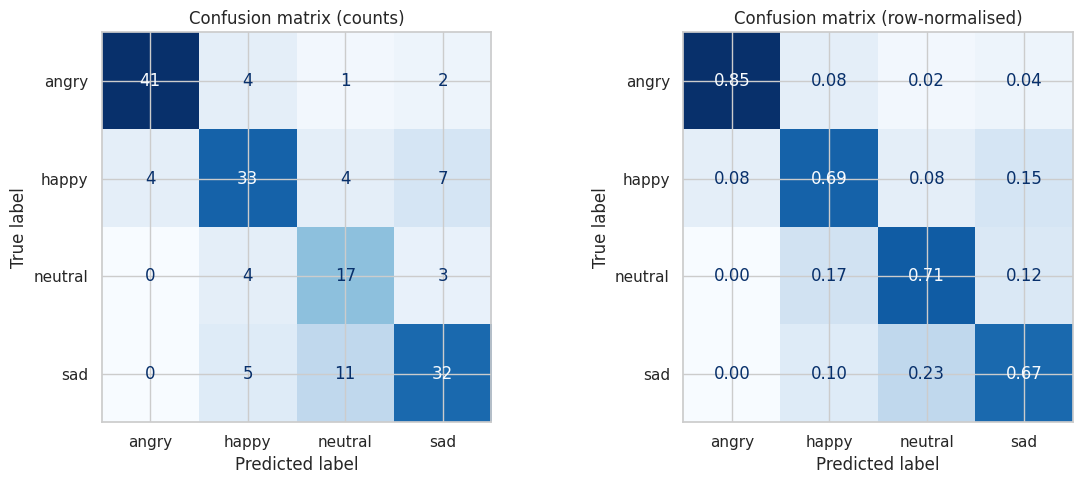

In [37]:
cm = confusion_matrix(y_test, y_pred, labels=CLASSES)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
ConfusionMatrixDisplay(cm, display_labels=CLASSES).plot(ax=axes[0], cmap="Blues", colorbar=False)
axes[0].set_title("Confusion matrix (counts)")
ConfusionMatrixDisplay(cm / cm.sum(axis=1, keepdims=True), display_labels=CLASSES).plot(
    ax=axes[1], cmap="Blues", colorbar=False, values_format=".2f")
axes[1].set_title("Confusion matrix (row-normalised)")
plt.tight_layout(); plt.savefig(f"{OUT_DIR}/confusion_matrix.png", dpi=150); plt.show()

## 8. Save the model and metrics (used by the dashboard)

In [38]:
joblib.dump(final_model, f"{OUT_DIR}/model.joblib")

metrics = {
    "model": BEST_MODEL, "feature_set": BEST_FS, "training_regime": BEST_REG,
    "feature_indices": [FEATURE_NAMES.index(c) for c in final_cols],
    "sample_rate": SR, "n_mfcc": N_MFCC, "classes": list(final_model.classes_),
    "train_actors": TRAIN_ACTORS, "test_actors": TEST_ACTORS,
    "class_counts_all": {k: int(v) for k, v in counts.items()},
    "n_train_original": int((train_df.aug == "orig").sum()), "n_train_total": int(len(train_df)),
    "n_test": int(len(test_df)),
    "accuracy": round(float(acc), 4), "macro_f1": round(float(macro_f1), 4),
    "confusion_matrix": cm.tolist(),
    "per_class_report": classification_report(y_test, y_pred, labels=CLASSES, output_dict=True),
    "experiments": res_df.drop(columns="best_params").round(4).to_dict(orient="records"),
}
with open(f"{OUT_DIR}/metrics.json", "w") as f:
    json.dump(metrics, f, indent=2)
print("Saved: model.joblib, metrics.json, confusion_matrix.png, class_counts.png, features.py")

Saved: model.joblib, metrics.json, confusion_matrix.png, class_counts.png, features.py


## 9. Error analysis

In [39]:
recall = {c: cm[i, i] / cm[i].sum() for i, c in enumerate(CLASSES)}
print("Recall per emotion:", {k: round(v, 3) for k, v in recall.items()})
print("Best recognised :", max(recall, key=recall.get), "| worst:", min(recall, key=recall.get), "\n")

errors = [(CLASSES[i], CLASSES[j], cm[i, j], cm[i, j] / cm[i].sum())
          for i in range(4) for j in range(4) if i != j]
pd.DataFrame(errors, columns=["true", "predicted_as", "count", "share_of_true_class"]
             ).sort_values("count", ascending=False).head(5).round(3)

Recall per emotion: {'angry': np.float64(0.854), 'happy': np.float64(0.688), 'neutral': np.float64(0.708), 'sad': np.float64(0.667)}
Best recognised : angry | worst: sad 



,true,predicted_as,count,share_of_true_class
11,sad,neutral,11,0.229
5,happy,sad,7,0.146
10,sad,happy,5,0.104
0,angry,happy,4,0.083
7,neutral,happy,4,0.167


### Confusion analysis
> **Write 3-4 sentences here from your own results** (confusion matrix + table above):
> 1. Which emotion is recognised best and which worst?
> 2. Which pairs are confused most (e.g. `neutral` <-> `sad`, `angry` <-> `happy`)?
> 3. A likely reason (similar energy/pitch, small `neutral` class, only 18 training voices, acted speech).
> 4. One thing that could reduce the confusion.

## 10. Optional: small CNN on mel spectrograms
Set `RUN_CNN = True` in Section 1 to run this. Same actor split; actors 15-18 (from the training actors) are used for validation/early stopping, so the test actors stay untouched. With only 672 clips a CNN usually does **not** beat a good SVM on hand-made features; that is a valid finding for the report.

In [40]:
if RUN_CNN:
    import tensorflow as tf
    from tensorflow.keras import layers, models as kmodels, callbacks
    from sklearn.utils.class_weight import compute_class_weight
    tf.random.set_seed(SEED)

    N_SAMPLES, N_MELS = int(3.0 * SR), 64
    def mel_spec(path):
        y = librosa.util.fix_length(load_audio(path), size=N_SAMPLES)
        return librosa.power_to_db(librosa.feature.melspectrogram(y=y, sr=SR, n_mels=N_MELS), ref=np.max)

    orig = feat_df[feat_df.aug == "orig"].reset_index(drop=True)
    spec_all = np.array([mel_spec(p) for p in orig["path"]])[..., np.newaxis]
    lab_all  = orig["emotion"].map({c: i for i, c in enumerate(CLASSES)}).values
    act_all  = orig["actor"].values

    VAL_ACTORS = [15, 16, 17, 18]
    tr = np.isin(act_all, [a for a in TRAIN_ACTORS if a not in VAL_ACTORS])
    va = np.isin(act_all, VAL_ACTORS)
    te = np.isin(act_all, TEST_ACTORS)
    mu, sd = spec_all[tr].mean(), spec_all[tr].std()
    spec_all = (spec_all - mu) / sd

    def block(f):
        return [layers.Conv2D(f, 3, padding="same"), layers.BatchNormalization(),
                layers.Activation("relu"), layers.MaxPooling2D(2)]
    cnn = kmodels.Sequential([layers.Input(shape=spec_all.shape[1:])]
        + block(16) + block(32) + block(64) + block(64)
        + [layers.GlobalAveragePooling2D(), layers.Dropout(0.3),
           layers.Dense(64, activation="relu"), layers.Dense(len(CLASSES), activation="softmax")])
    cnn.compile(optimizer=tf.keras.optimizers.Adam(1e-3),
                loss="sparse_categorical_crossentropy", metrics=["accuracy"])

    cw = compute_class_weight("balanced", classes=np.arange(4), y=lab_all[tr])
    cnn.fit(spec_all[tr], lab_all[tr], validation_data=(spec_all[va], lab_all[va]),
            epochs=150, batch_size=16, class_weight=dict(enumerate(cw)),
            callbacks=[callbacks.EarlyStopping(patience=20, restore_best_weights=True),
                       callbacks.ReduceLROnPlateau(factor=0.5, patience=7)], verbose=2)

    cnn_pred = cnn.predict(spec_all[te]).argmax(axis=1)
    cnn_acc, cnn_f1 = accuracy_score(lab_all[te], cnn_pred), f1_score(lab_all[te], cnn_pred, average="macro")
    display(pd.DataFrame([
        {"model": f"{BEST_MODEL} + {BEST_FS}", "accuracy": acc, "macro_f1": macro_f1},
        {"model": "Small CNN (mel spectrogram)", "accuracy": cnn_acc, "macro_f1": cnn_f1}]).round(3))
else:
    print("CNN skipped (RUN_CNN = False).")

CNN skipped (RUN_CNN = False).


## Summary and next steps
**Done:** filtered RAVDESS to 4 emotions (672 clips), explored the audio, built an extended acoustic feature set, trained SVM and Random Forest with balanced class weights, tuned with actor-grouped cross-validation, compared with/without augmentation, and evaluated on 6 unseen actors.

**With more time:** pretrained speech embeddings (wav2vec2 / HuBERT), leave-one-actor-out evaluation, more augmentation, all 8 emotions, and testing on other emotional-speech datasets.

In [41]:
  import sklearn; print(sklearn.__version__)

1.6.1
The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.
